In [1]:
import matplotlib.pyplot as plt
import pandas as pd

0      0.0738
1      0.4826
2      0.5772
3      0.7926
4      0.9628
        ...  
995    1.0000
996    1.0000
997    1.0000
998    1.0000
999    1.0000
Name: Readout, K=512, L=32, p_B=1.0, p_C=0.0, B=4, eps=0 - ic1_acc, Length: 1000, dtype: float64


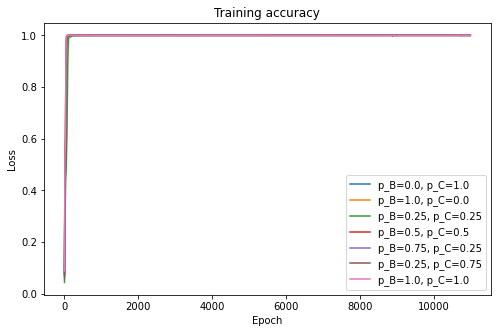

In [2]:
pb_pc = pd.read_csv("./pbpc.csv")

pb_pc = pb_pc[pb_pc.columns.drop(list(pb_pc.filter(regex='MIN')))]
pb_pc = pb_pc[pb_pc.columns.drop(list(pb_pc.filter(regex='MAX')))]
step = pb_pc["Step"]

# For plotting specific type of accuracy (ic1, ic2, iw, test)
pb_pc = pb_pc.filter(regex='ic1')
pb_pc["Step"] = step

print(pb_pc["Readout, K=512, L=32, p_B=1.0, p_C=0.0, B=4, eps=0 - ic1_acc"])

ax = pb_pc.plot(x='Step', y=pb_pc.columns.drop("Step"), kind='line', figsize=(8, 5))

import re
pattern = r"(p_B=[+-]?\d+(\.\d+)?,\s?p_C=[+-]?\d+(\.\d+)?)"

# Extract existing legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Replace each label with its first letter
short_labels = [re.search(pattern, label).group(1) for label in labels]

# Update the legend with new labels
ax.legend(handles, short_labels)

# Display the plot
plt.title("Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

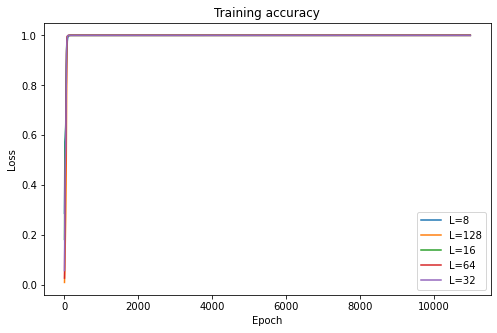

In [3]:
L_csv = pd.read_csv("./L.csv")

L_csv = L_csv[L_csv.columns.drop(list(L_csv.filter(regex='MIN')))]
L_csv = L_csv[L_csv.columns.drop(list(L_csv.filter(regex='MAX')))]
step = L_csv["Step"]

# For plotting specific type of accuracy (ic1, ic2, iw, test)
L_csv = L_csv.filter(regex='ic2')
L_csv["Step"] = step

ax_L = L_csv.plot(x='Step', y=L_csv.columns.drop("Step"), kind='line', figsize=(8, 5))

import re
pattern = r"(L=[+-]?\d+)"

# Extract existing legend handles and labels
handles, labels = ax_L.get_legend_handles_labels()

# Replace each label with its first letter
short_labels = [re.search(pattern, label).group(1) for label in labels]

# Update the legend with new labels
ax_L.legend(handles, short_labels)

# Display the plot
plt.title("Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

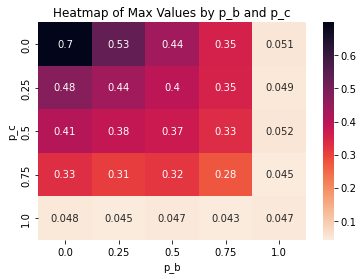

In [17]:
import re

df = pd.read_csv("./pbpc4.csv")
df = df[df.columns.drop(list(df.filter(regex='MIN')))]
df = df[df.columns.drop(list(df.filter(regex='MAX')))]
step = df["Step"]

# (ic1, ic2, iw, test)
df = df.filter(regex='iw')
df["Step"] = step

pattern = re.compile(r"p_B=([+-]?\d+(?:\.\d+)?),\s?p_C=([+-]?\d+(?:\.\d+)?)")

records = []  # will store tuples: (p_b, p_c, max_value)
seen_pairs = set()

for col in df.columns:
    match = pattern.search(col)
    if match:
        # Extract float values from column name
        p_b_val = float(match.group(1))
        p_c_val = float(match.group(2))
        
        # Take the maximum value of that column across all rows
        max_val = df[col].max()
        # max_val = df[col].iloc[10]
        # max_val = df[col].iloc[2]
        
        if (p_b_val, p_c_val) not in seen_pairs:
            seen_pairs.add((p_b_val, p_c_val))
            records.append((p_b_val, p_c_val, max_val))

parsed_df = pd.DataFrame(records, columns=["p_b", "p_c", "max_value"])
heatmap_df = parsed_df.pivot(index="p_c", columns="p_b", values="max_value")

import seaborn as sns
import matplotlib.pyplot as plt

sns.color_palette("rocket_r", as_cmap=True)

sns.heatmap(heatmap_df, annot=True, cmap="rocket_r")
# sns.heatmap(heatmap_df, annot=False, cmap="rocket_r")
plt.title("Heatmap of Max Values by p_b and p_c")
plt.xlabel("p_b")
plt.ylabel("p_c")
plt.show()


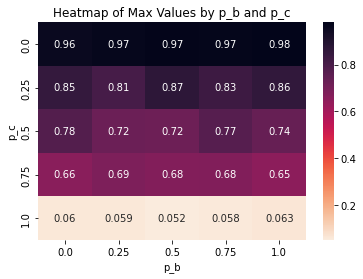

In [16]:
import re

df = pd.read_csv("./pbpc6.csv")
df = df[df.columns.drop(list(df.filter(regex='MIN')))]
df = df[df.columns.drop(list(df.filter(regex='MAX')))]
step = df["Step"]

# (ic1, ic2, iw, test)
df = df.filter(regex='iw')
df["Step"] = step

pattern = re.compile(r"p_B=([+-]?\d+(?:\.\d+)?),\s?p_C=([+-]?\d+(?:\.\d+)?)")

records = []  # will store tuples: (p_b, p_c, max_value)
seen_pairs = set()

for col in df.columns:
    match = pattern.search(col)
    if match:
        # Extract float values from column name
        p_b_val = float(match.group(1))
        p_c_val = float(match.group(2))
        
        # Take the maximum value of that column across all rows
        max_val = df[col].max()
        # max_val = df[col].iloc[10]
        # max_val = df[col].iloc[2]
        
        if (p_b_val, p_c_val) not in seen_pairs:
            seen_pairs.add((p_b_val, p_c_val))
            records.append((p_b_val, p_c_val, max_val))

parsed_df = pd.DataFrame(records, columns=["p_b", "p_c", "max_value"])
heatmap_df = parsed_df.pivot(index="p_c", columns="p_b", values="max_value")

import seaborn as sns
import matplotlib.pyplot as plt

sns.color_palette("rocket_r", as_cmap=True)

sns.heatmap(heatmap_df, annot=True, cmap="rocket_r")
# sns.heatmap(heatmap_df, annot=False, cmap="rocket_r")
plt.title("Heatmap of Max Values by p_b and p_c")
plt.xlabel("p_b")
plt.ylabel("p_c")
plt.show()
